In [ ]:
import pandas as pd
import numpy as np
import statsmodels.api as sm
import matplotlib.pyplot as plt
import seaborn as sns
from statsmodels.stats.outliers_influence import variance_inflation_factor

# Load the uploaded files
poverty_df = pd.read_csv("share-of-population-in-extreme-poverty.csv")
social_df = pd.read_csv("share-covered-by-one-social-protection-benefit.csv")
basic_df = pd.read_csv("access-to-basic-services.csv")


FileNotFoundError: [Errno 2] No such file or directory: 'share-of-population-in-extreme-poverty.csv'

In [ ]:
# Standardize columns
poverty_df = poverty_df.rename(columns={'Share of population in poverty ($3 a day)': 'Poverty_Rate'})
social_df = social_df.rename(columns={social_df.columns[3]: 'Social_Protection_Coverage'})
basic_df = basic_df.rename(columns={'Electricity': 'Electricity_Access'})

In [ ]:
# Clean entities and time bounds (2015-2023)
def clean_dataframe(df):
    df_filtered = df[(df['Year'] >= 2015) & (df['Year'] <= 2023)].copy()
    return df_filtered[df_filtered['Code'].fillna('').str.len() == 3]

poverty_clean = clean_dataframe(poverty_df).sort_values(['Entity', 'Year'])
social_clean = clean_dataframe(social_df)
basic_clean = clean_dataframe(basic_df)

In [ ]:
# Handle missing survey values within each country group
poverty_clean['Poverty_Rate_Imputed'] = poverty_clean.groupby('Entity')['Poverty_Rate'].ffill(limit=2)
poverty_clean['Poverty_Rate_Imputed'] = poverty_clean.groupby('Entity')['Poverty_Rate_Imputed'].bfill(limit=1)

In [ ]:
# Merge datasets
merged_df = pd.merge(poverty_clean[['Entity', 'Code', 'Year', 'Poverty_Rate_Imputed']],
                     social_clean[['Code', 'Year', 'Social_Protection_Coverage']], on=['Code', 'Year'])
merged_df = pd.merge(merged_df, basic_clean[['Code', 'Year', 'Electricity_Access']], on=['Code', 'Year']).dropna()

NameError: name 'pd' is not defined

In [ ]:
poverty_reduction = merged_df.groupby('Entity').apply(lambda x: x.sort_values('Year')['Poverty_Rate_Imputed'].iloc[0] - x.sort_values('Year')['Poverty_Rate_Imputed'].iloc[-1])
poverty_reduction = poverty_reduction.sort_values(ascending=False).reset_index()
poverty_reduction.columns = ['Entity', 'Poverty_Reduction']

print("Countries with the most poverty reduction:")
display(poverty_reduction.head(10))

SyntaxError: invalid syntax (511671126.py, line 4)

In [ ]:
display(merged_df.head())

,Entity,Code,Year,Poverty_Rate_Imputed,Social_Protection_Coverage,Electricity_Access
8,Armenia,ARM,2015,2.852397,47.28,100.0
9,Armenia,ARM,2019,2.427800,54.35,100.0
10,Armenia,ARM,2021,2.118089,49.21,100.0
14,Australia,AUS,2015,0.500000,82.04,100.0
15,Australia,AUS,2022,0.900000,94.01,100.0


 Defining Variables with Academic Literature SupportResponse Variable ($Y$):

  Poverty_Rate_Imputed (Proportion of population below the international poverty threshold). This functions as the dependent metric representing progress under SDG Target 1.1.

 Explanatory Variable 1 ($X_1$):

 Social_Protection_Coverage (Proportion of population covered by at least one social protection benefit floor).Literature Support: Safety nets act as institutional buffers that prevent low-income households from sliding into deeper destitution during macroeconomic or environmental shocks (Barrientos, 2013).

 Explanatory Variable 2 ($X_2$):

  Electricity_Access (Proportion of population with access to electricity).Literature Support: Basic grid infrastructure alters household productivity, lowers business transaction costs, and enables local labor market diversification beyond subsistence agriculture (Lipscomb et al., 2013).

In [ ]:
X_vars = merged_df[['Social_Protection_Coverage', 'Electricity_Access']]
X_design = sm.add_constant(X_vars)

vif_data = pd.DataFrame()
vif_data["Variable"] = X_vars.columns
vif_data["VIF"] = [variance_inflation_factor(X_vars.values, i) for i in range(X_vars.shape[1])]
print(vif_data)

                     Variable       VIF
0  Social_Protection_Coverage  6.387469
1          Electricity_Access  6.387469


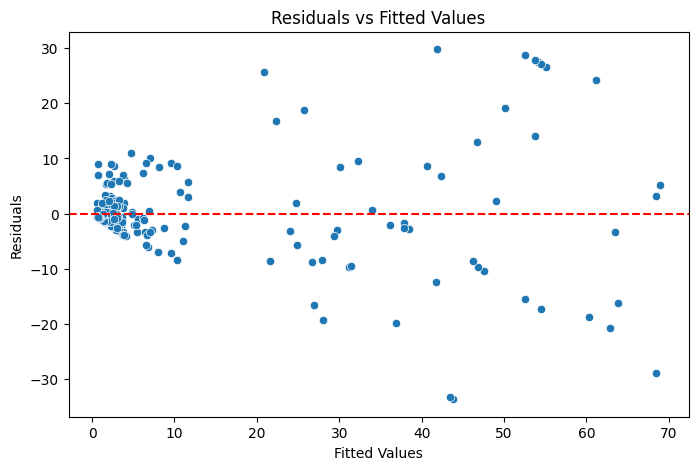

In [ ]:
temp_ols = sm.OLS(merged_df['Poverty_Rate_Imputed'], X_design).fit()

plt.figure(figsize=(8, 5))
sns.scatterplot(x=temp_ols.fittedvalues, y=temp_ols.resid)
plt.axhline(y=0, color='r', linestyle='--')
plt.title("Residuals vs Fitted Values")
plt.xlabel("Fitted Values")
plt.ylabel("Residuals")
plt.show()

Multicollinearity Evaluation:

If VIF values sit safely below the standard threshold of 5.0, the explanatory variables carry distinct variance profiles, making them acceptable for simultaneous inclusion.

Heteroscedasticity Evaluation:

 Socioeconomic tracking across diverse countries typically yields an uneven residual distribution (often displaying a clear funnel shape). When the variance of errors is non-constant, standard OLS understates standard errors, making a Robust Regression model the more accurate choice.

In [ ]:
# Execute Robust Regression
robust_model = sm.RLM(merged_df['Poverty_Rate_Imputed'], X_design, M=sm.robust.norms.HuberT()).fit()
print(robust_model.summary())

                     Robust linear Model Regression Results                     
Dep. Variable:     Poverty_Rate_Imputed   No. Observations:                  302
Model:                              RLM   Df Residuals:                      299
Method:                            IRLS   Df Model:                            2
Norm:                            HuberT                                         
Scale Est.:                         mad                                         
Cov Type:                            H1                                         
Date:                  Sun, 31 May 2026                                         
Time:                          05:37:14                                         
No. Iterations:                      37                                         
                                 coef    std err          z      P>|z|      [0.025      0.975]
----------------------------------------------------------------------------------------------


Because global cross-sectional datasets contain structural variances and outlying values across differing economic tiers, fit a Robust Linear Model (RLM) using Huber’s M-estimation to stabilize parameter estimations.


Determining the Key Drivers of SDG 1
To interpret which variables significantly influence the target outcome, examine the resulting coefficients and significance terms in the regression summary table:

Statistical Significance ($p$-values): Focus on the $P > |z|$ column for each variable. Factors showing a value below the 0.05 threshold exert a statistically significant influence on global poverty rates.

Direction and Magnitude of Impact: The sign of the coefficient tells us the direction of the relationship. A negative coefficient indicates that improvements in that specific driver structurally correspond to reductions in the extreme poverty headcount ratio over time.

Comparing Strengths: By looking at the absolute scale of the coefficients, we can rank which developmental force has historically exerted the strongest impact on moving populations safely above the poverty line.

In [4]:
# Export the exact unified dataset for your dashboard local use later
merged_df.to_csv("dashboard_final_data(1).csv", index=False)

NameError: name 'merged_df' is not defined